# Unsupervised Structure Discovery (Density Clustering)

This notebook utilizes HDBSCAN to identify dense "clouds" of constructs.
We sweep hyperparameters (`cluster_selection_epsilon`, `min_cluster_size`) and optimize for F1-score on the calibration set (ground truth pairs).

In [1]:
import pandas as pd
import model_utils_clustering as model_utils
import model_utils_shared
import config
import warnings

# Silence warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Reproducibility
model_utils_shared.setup_reproducibility(config.SEED)

/home/rass/Desktop/SocialScience-ConceptIntegration/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


42

## 1. Load Data

In [2]:
pos_path = config.DATA_PATHS['pos_pairs']
neg_path = config.DATA_PATHS['neg_pairs']

df = model_utils_shared.load_and_prepare_data(pos_path, neg_path, config.SEED)
print(f"Total Rows: {len(df)}")

Loading datasets...
Positive samples: 3587
Negative samples (total): 2884723
Negative samples (used as is): 2884723
Total Rows: 2888310


## 2. Clustering Run (Fixed Params)

Run one clustering pass per model using predefined parameters, then evaluate results separately.


 Processing: All-MPNet-Base-v2
Loading Model (all-mpnet-base-v2)...
Computed embeddings for 4270 unique terms.
Optimizing Clustering for All-MPNet-Base-v2...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using original embeddings (768 dims)...
768        | 2          | 2          | 0.5085     | 0.6485     | 0.4182     | 0.4182     | 0.9997
768        | 2          | 3          | 0.4105     | 0.4697     | 0.3647     | 0.3647     | 0.9995
768        | 2          | 4          | 0.3020     | 0.4289     | 0.2331     | 0.2331     | 0.9996
768        | 2          | 5          | 0.0024     | 0.0012     | 0.9746     | 0.9746     | 0.0091
768        | 2          | 6          | 0.0025     | 0.0013     | 0.8185     | 0.8185     | 0.1928
768        | 2          | 7          | 0.0025     | 0.0012     | 0.8450     | 0.8450     | 0.1504


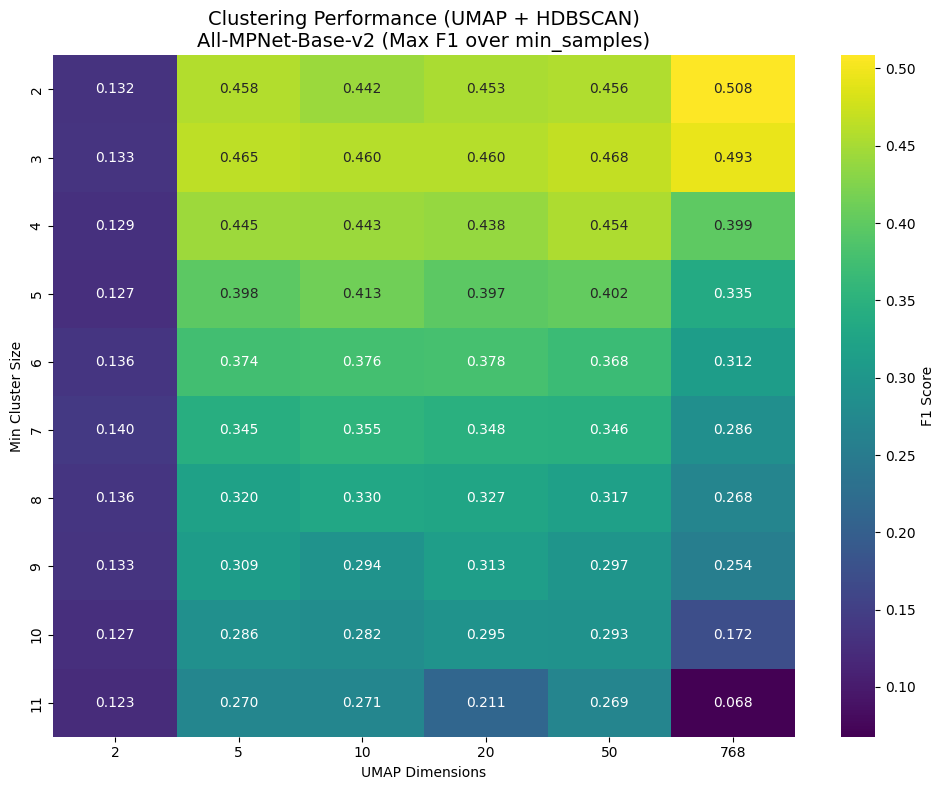


 Processing: MPNet-Personality
Loading Model (dwulff/mpnet-personality)...
Computed embeddings for 4270 unique terms.
Optimizing Clustering for MPNet-Personality...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using original embeddings (768 dims)...
768        | 2          | 2          | 0.4823     | 0.6259     | 0.3922     | 0.3922     | 0.9997
768        | 2          | 3          | 0.4119     | 0.4682     | 0.3677     | 0.3677     | 0.9995
768        | 2          | 4          | 0.3193     | 0.3649     | 0.2838     | 0.2838     | 0.9994
768        | 2          | 5          | 0.2451     | 0.2906     | 0.2119     | 0.2119     | 0.9994
768        | 2          | 6          | 0.0026     | 0.0013     | 0.8068     | 0.8068     | 0.2232
768        | 2          | 7          | 0.0025     | 0.0013     | 0.8447     | 0.8447     | 

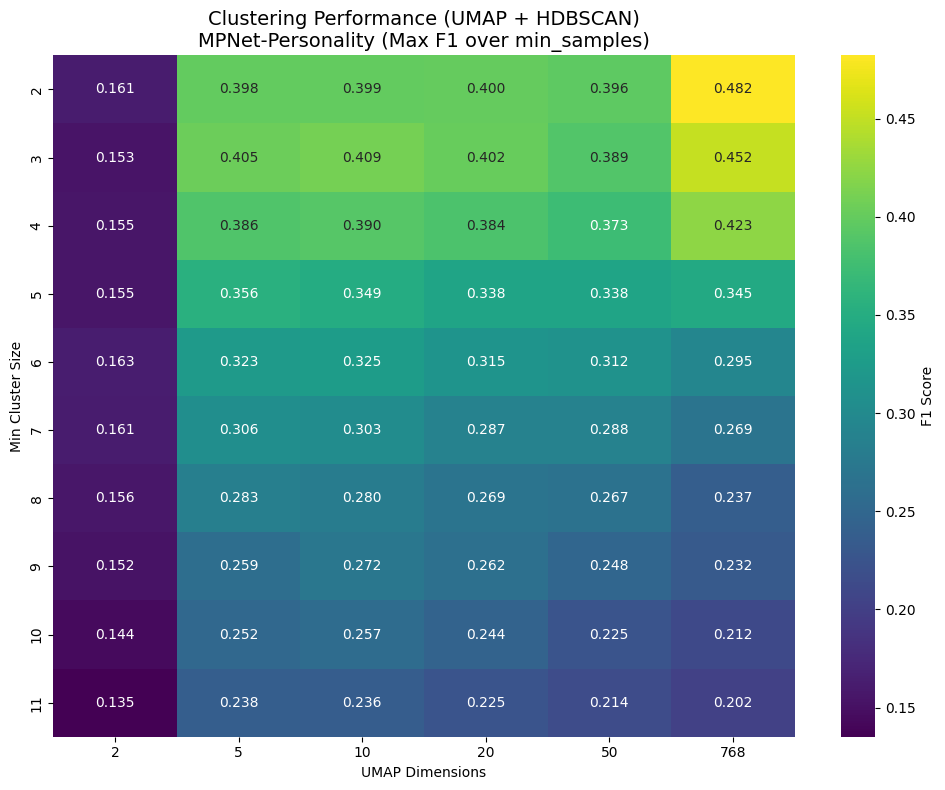


 Processing: SciBERT (SciVocab)
Loading Model (allenai/scibert_scivocab_uncased)...
Computed embeddings for 4270 unique terms.
Optimizing Clustering for SciBERT (SciVocab)...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using original embeddings (768 dims)...
768        | 2          | 2          | 0.3088     | 0.4662     | 0.2308     | 0.2308     | 0.9997
768        | 2          | 3          | 0.1836     | 0.2068     | 0.1650     | 0.1650     | 0.9992
768        | 2          | 4          | 0.0025     | 0.0013     | 0.9208     | 0.9208     | 0.0910
768        | 2          | 5          | 0.0025     | 0.0013     | 0.9629     | 0.9629     | 0.0485
768        | 2          | 6          | 0.0025     | 0.0013     | 0.8734     | 0.8734     | 0.1334
768        | 2          | 7          | 0.0025     | 0.0012     | 0.8171     | 0.8

In [ ]:
models_to_test = config.MODELS
all_clustering_results = []

for model_name, model_conf in models_to_test.items():
    display_name = model_conf['display_name']
    print(f"\n{'='*50}")
    print(f" Processing: {display_name}")
    print(f"{'='*50}")

    # 1. Load Model
    model = model_utils_shared.load_model(model_name, model_type=model_conf['type'])
    if model is None:
        continue

    # 2. Get Embeddings for unique terms
    unique_terms, embeddings = model_utils.get_unique_terms_embeddings(model, df)

    # 3. Sweep Hyperparameters (UMAP Components + Min Cluster Size)
    results, best_params = model_utils.run_clustering_optimization(
        display_name, 
        unique_terms, 
        embeddings, 
        df, 
        config.CLUSTERING_PARAMS['min_cluster_sizes'],
        config.CLUSTERING_PARAMS['min_samples'],
        config.CLUSTERING_PARAMS['umap_n_components']
    )
    
    all_clustering_results.extend(results)

    # 4. Plot Heatmap
    results_df = pd.DataFrame(results)
    model_utils.plot_clustering_heatmap(results_df, display_name)

## 3. Summary of Best Clustering Configurations

In [4]:
full_results_df = pd.DataFrame(all_clustering_results)

# Print Summary
model_utils.print_best_clustering_settings(full_results_df)

timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
full_results_df.to_csv(f'results/clustering_results_{timestamp}.csv', index=False)
print(f"\nFull clustering results saved to results/clustering_results_{timestamp}.csv")


 BEST CLUSTERING SETTINGS PER MODEL 

Model: All-MPNet-Base-v2
  Max F1: 0.5132
  Precision: 0.6459
  Recall: 0.4257
  Pos Acc: 0.4257
  Neg Acc: 0.9997
  UMAP Dims: 768
  Min Cluster Size: 2
  Clusters Found: 1056
  Noise Points: 1212

Model: MPNet-Personality
  Max F1: 0.4835
  Precision: 0.6079
  Recall: 0.4014
  Pos Acc: 0.4014
  Neg Acc: 0.9997
  UMAP Dims: 768
  Min Cluster Size: 2
  Clusters Found: 1058
  Noise Points: 1200

Model: SciBERT (SciVocab)
  Max F1: 0.3123
  Precision: 0.4665
  Recall: 0.2347
  Pos Acc: 0.2347
  Neg Acc: 0.9997
  UMAP Dims: 768
  Min Cluster Size: 2
  Clusters Found: 916
  Noise Points: 1636

Model: BERT Base
  Max F1: 0.3036
  Precision: 0.5029
  Recall: 0.2175
  Pos Acc: 0.2175
  Neg Acc: 0.9997
  UMAP Dims: 768
  Min Cluster Size: 2
  Clusters Found: 885
  Noise Points: 1830

Full clustering results saved to results/clustering_results_20260120_013851.csv
